In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


In [12]:
# parameters
a_bn = 0.145e-9 #m
a = 2*a_bn #m
k = 300 #N/m
m_b = 10.81 * 1.66e-27 #kg
m_n = 14.01 * 1.66e-27 #kg

hbar = 1.0545718e-34 #J*s
k_B = 1.38064852e-23 #J/K

J_to_eV = 1.60217662e-19 #J/eV
eV_to_K = 8.617e-5 #eV/K

## (a)

$$D_{red} \vec{u} = \omega^2  \vec{u} $$

In [13]:
def e_from_q(q): #returns (e_opt_eV, e_ac_eV) in eV
    D_red = np.array([[2*k/m_b, -k*(1 + np.exp(1j*q*a))/m_b], 
                      [-k*(1 + np.exp(-1j*q*a))/m_n, 2*k/m_n]])
    w2 = np.linalg.eigvals(D_red)
    e_ac_eV = hbar * np.sqrt(np.real(w2[1])) / J_to_eV 
    e_opt_eV = hbar * np.sqrt(np.real(w2[0])) / J_to_eV 
    return e_opt_eV, e_ac_eV

In [14]:
e_opt_eV = []
e_ac_eV = []
momentum = np.linspace(-np.pi/a, np.pi/a, 201)
for q in momentum:
    e_opt_eV_val, e_ac_eV_val = e_from_q(q)
    e_opt_eV.append(e_opt_eV_val)
    e_ac_eV.append(e_ac_eV_val)

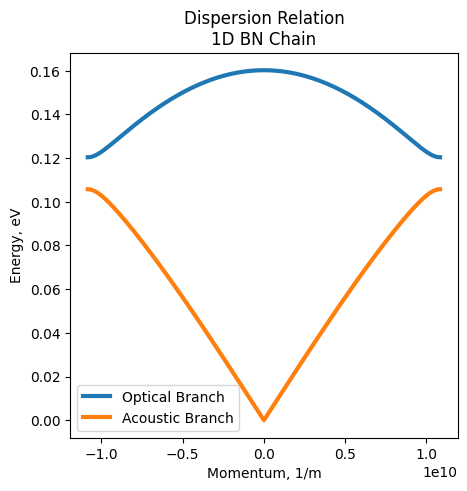

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(momentum, e_opt_eV, label='Optical Branch', linewidth=3)
ax.plot(momentum, e_ac_eV, label='Acoustic Branch', linewidth=3)
ax.set_xlabel('Momentum, 1/m')
ax.set_ylabel('Energy, eV')
ax.set_title('Dispersion Relation\n1D BN Chain')
ax.legend()
plt.show()
fig.tight_layout()
fig.savefig('dispersion_relation.png', dpi=300)

## (b)

In [16]:
def Bose_Einstein(E, T):
    # E is the energy of the state in eV
    # T is the temperature in K
    return 1 / (np.exp(E / (eV_to_K * T))-1)

In [17]:
q_list = np.linspace(np.pi/a * 0.1, np.pi/a, 4)
T_range = np.linspace(1, 300, 100)
e_opt_eV_dict = {}
e_ac_eV_dict = {}
N_opt_dict = {}
N_ac_dict = {}

for q in q_list:
    e_opt_eV_dict[q] = []
    e_ac_eV_dict[q] = []
    N_opt_dict[q] = []
    N_ac_dict[q] = []

    for T in T_range:
        e_opt_eV_val = Bose_Einstein(e_from_q(q)[0], T)*e_from_q(q)[0]
        e_ac_eV_val = Bose_Einstein(e_from_q(q)[1], T)*e_from_q(q)[1]
        n_opt_val = Bose_Einstein( e_from_q(q)[0], T)
        n_ac_val = Bose_Einstein(e_from_q(q)[1], T)
        e_opt_eV_dict[q].append(e_opt_eV_val)
        e_ac_eV_dict[q].append(e_ac_eV_val)
        N_opt_dict[q].append(n_opt_val)
        N_ac_dict[q].append(n_ac_val)
    


/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_51809/871100290.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp(E / (eV_to_K * T))-1)


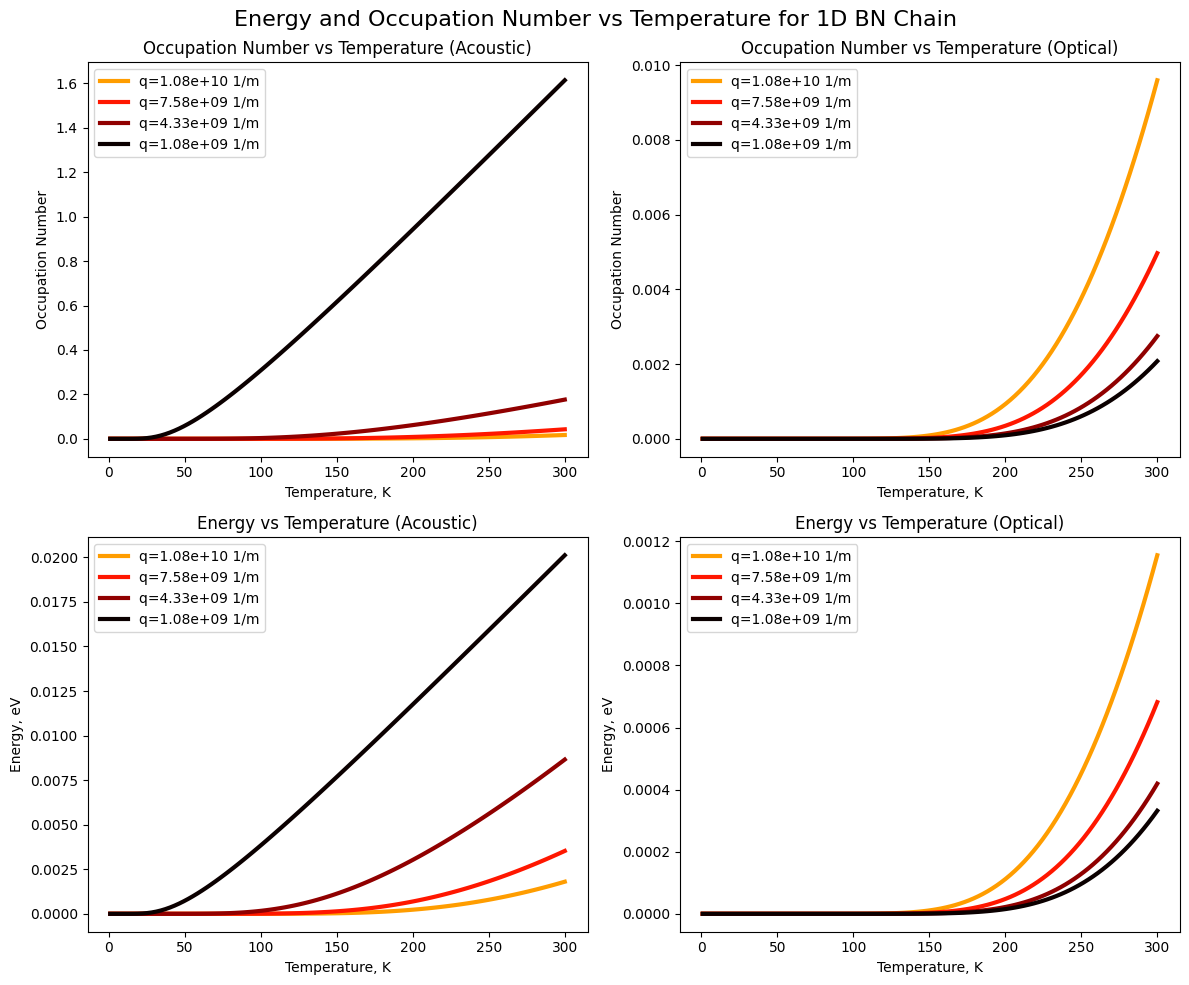

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax2, ax1 = axes[1]
ax4, ax3 = axes[0]

colors = cm.hot(np.linspace(0, 1, len(q_list)+2))

for q in q_list[::-1]:
    q_index = q_list.tolist().index(q)
    ax1.plot(T_range, e_opt_eV_dict[q], label=f'q={q:.2e} 1/m', color=colors[q_index], linewidth=3)
    ax2.plot(T_range, e_ac_eV_dict[q], label=f'q={q:.2e} 1/m', color=colors[q_index], linewidth=3)
    ax3.plot(T_range, N_opt_dict[q], label=f'q={q:.2e} 1/m', color=colors[q_index], linewidth=3)
    ax4.plot(T_range, N_ac_dict[q], label=f'q={q:.2e} 1/m', color=colors[q_index], linewidth=3)

ax1.set_xlabel('Temperature, K')
ax1.set_ylabel('Energy, eV')
ax1.set_title('Energy vs Temperature (Optical)')
ax1.legend()

ax2.set_xlabel('Temperature, K')
ax2.set_ylabel('Energy, eV')
ax2.set_title('Energy vs Temperature (Acoustic)')
ax2.legend()

ax3.set_xlabel('Temperature, K')
ax3.set_ylabel('Occupation Number')
ax3.set_title('Occupation Number vs Temperature (Optical)')
ax3.legend()

ax4.set_xlabel('Temperature, K')
ax4.set_ylabel('Occupation Number')
ax4.set_title('Occupation Number vs Temperature (Acoustic)')
ax4.legend()

fig.suptitle('Energy and Occupation Number vs Temperature for 1D BN Chain', fontsize=16)
plt.tight_layout()
plt.show()
fig.savefig('energy_occupation_vs_temperature.png', dpi=300)

## (C)

In [19]:
def U(T):
    U_opt = 0
    U_ac = 0
    for q in q_list:
        U_opt += Bose_Einstein(e_from_q(q)[0], T)*e_from_q(q)[0]
        U_ac += Bose_Einstein(e_from_q(q)[1], T)*e_from_q(q)[1]
    return (U_opt + U_ac)*J_to_eV
M = 201*(m_b + m_n)
def C(T):
    dT = 1e-6
    return 1/M * (U(T + dT) - U(T)) / dT

/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_51809/871100290.py:4: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp(E / (eV_to_K * T))-1)


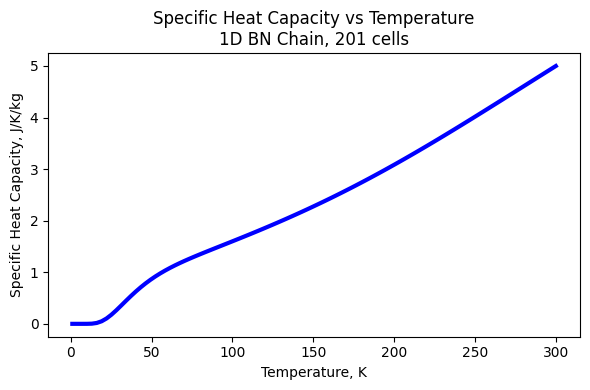

In [20]:
C_values = [C(T) for T in T_range]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T_range, C_values, color='blue', linewidth=3)
ax.set_xlabel('Temperature, K')
ax.set_ylabel('Specific Heat Capacity, J/K/kg')
ax.set_title('Specific Heat Capacity vs Temperature\n1D BN Chain, 201 cells')
fig.tight_layout()
fig.savefig('heat_capacity_vs_temperature.png', dpi=300)